In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [73]:
class Perceptron:
    def __init__(self, learning_rate, boundary):
        self.learning_rate = learning_rate
        self.boundary = boundary
        self.weights_history = []

    def activation_function(self, potential):
        return 1 if potential >= 0 else 0

    def fit(self, X, labels, w, epochs):
        """
        Learning algorithm
        """

        # First start with a initialized weights vector
        self.weights_history = [w.copy()]
        print(f"W[0] = {w} ")
        for epoch in range(epochs):
            print("Época ", epoch)
            for i in range(len(X)):
                potential = np.dot(X[i], w) - self.boundary
            
                y = self.activation_function(potential)
    
                error = labels[i] - y

                if error != 0:
                    w = w + self.learning_rate * error * X[i]
                    self.weights_history.append(w.copy())
                    print(f"W[{i}] = {w} ")

    def get_weights_history(self):
        return self.weights_history

In [61]:
X = [[2, 5], [3, 4], [3, 6],
     [5, 1], [8, 2], [4, 5],
     [4, 6], [6, 1], [6, 2],
     [7, 3]]
labels = [0, 0, 0, 1, 1, 0, 0, 1, 1, 1]

X = np.asarray(X, dtype=np.float64)
labels = np.asarray(labels, dtype=np.int8)
print(X.shape)
print(labels.shape)

(10, 2)
(10,)


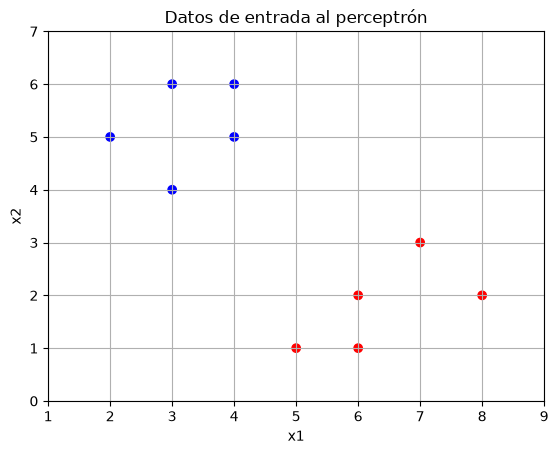

In [62]:
fig, ax = plt.subplots()

ax.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="bwr"
)

ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid()

line, = ax.plot([], [], color="black")
ax.set_title('Datos de entrada al perceptrón')
plt.show()

In [63]:
w = np.zeros(X.shape[1], dtype=np.float64)
learning_rate = 0.5
boundary = 1

print(w.shape)

(2,)


In [74]:
perceptron = Perceptron(learning_rate, boundary)

perceptron.fit(X, labels, w, 10)

W[0] = [0. 0.] 
Época  0
W[3] = [2.5 0.5] 
W[5] = [ 0.5 -2. ] 
W[8] = [ 3.5 -1. ] 
Época  1
W[0] = [ 2.5 -3.5] 
Época  2
Época  3
Época  4
Época  5
Época  6
Época  7
Época  8
Época  9


In [65]:
x1 = np.linspace(
    X[:, 0].min() - 1,
    X[:, 0].max() + 1,
    100
)

def update(frame):
    w_h = perceptron.weights_history[frame]

    if w_h[1] != 0:
        x2 = (perceptron.boundary - w_h[0] * x1) / w_h[1]
        line.set_data(x1, x2)
    else:
        line.set_data([], [])

    ax.set_title(f"Actualización {frame}")

    return line,

In [75]:
animation = FuncAnimation(
    fig,
    update,
    frames=len(perceptron.weights_history),
    interval=500,
    repeat=False
)

plt.close()
HTML(animation.to_jshtml())